In [1]:
import yfinance as yf
import pandas as pd

# 1. Setup the company ticker
ticker = "INFY.NS"
stock = yf.Ticker(ticker)

# 2. Extract DataFrames
income_statement = stock.financials
cash_flow = stock.cashflow

print("--- Step 1: Searching for row labels dynamically... ---")

# A robust way to find row names containing specific financial keywords
def find_row_name(df, keyword):
    for idx in df.index:
        if keyword.lower() in str(idx).lower():
            return idx
    return None

# Find the exact row names for our target company
rev_label = find_row_name(income_statement, 'Revenue')
net_inc_label = find_row_name(income_statement, 'Net Income')
ocf_label = find_row_name(cash_flow, 'Operating Cash Flow') or find_row_name(cash_flow, 'Operating Activities')
capex_label = find_row_name(cash_flow, 'Capital Expenditure') or find_row_name(cash_flow, 'Investing Activities')

# Validate that we found the data rows
if not all([rev_label, net_inc_label, ocf_label, capex_label]):
    print("Warning: Some financial row labels could not be mapped. Printing options:")
    print("Cash Flow Rows found:", list(cash_flow.index)[:5])
    # Hardcoded fallbacks if completely blank
    rev_label, net_inc_label = income_statement.index[0], income_statement.index[2]
    ocf_label, capex_label = cash_flow.index[0], cash_flow.index[1]

# 3. Pull Data and Ensure Chronological Order (Oldest Year to Newest Year)
# yfinance data frames usually put the newest year first. We invert it for modeling.
revenue = income_statement.loc[rev_label].iloc[::-1]
net_income = income_statement.loc[net_inc_label].iloc[::-1]
operating_cash_flow = cash_flow.loc[ocf_label].iloc[::-1]
capex = cash_flow.loc[capex_label].iloc[::-1]

# 4. Process and Clean Metrics
# If CapEx is recorded as a negative number, abs() ensures we treat it uniformly
historical_fcf = operating_cash_flow - capex.abs()
profit_margin = (net_income / revenue) * 100

# Consolidate into a clean historical DataFrame
summary_df = pd.DataFrame({
    'Revenue': revenue,
    'Net Income': net_income,
    'Profit Margin (%)': profit_margin,
    'Free Cash Flow': historical_fcf
})

print("\n--- Step 2: Historical Financial Summary Table ---")
print(summary_df)

# 5. The Forecasting Logic
print("\n--- Step 3: Generating 3-Year Projections... ---")

# Calculate the year-over-year growth rate of your FCF
fcf_growth_rates = historical_fcf.pct_change().dropna()
# Fallback: if growth is highly volatile or negative, default to a standard 5% conservative growth rate
avg_fcf_growth = fcf_growth_rates.mean() if fcf_growth_rates.mean() > 0 else 0.05

latest_fcf = historical_fcf.iloc[-1]  # The final element is now the newest year
forecast_years = ['2026', '2027', '2028']
projected_fcf = []

current_fcf = latest_fcf
for year in range(3):
    current_fcf = current_fcf * (1 + avg_fcf_growth)
    projected_fcf.append(current_fcf)

# Build the forecast table
forecast_df = pd.DataFrame({
    'Year': forecast_years,
    'Projected FCF': projected_fcf
})

print(forecast_df)

--- Step 1: Searching for row labels dynamically... ---

--- Step 2: Historical Financial Summary Table ---
                 Revenue    Net Income  Profit Margin (%)  Free Cash Flow
2022-03-31           NaN           NaN                NaN             NaN
2023-03-31  1.270900e+10  2.981000e+09          23.455819    2.534000e+09
2024-03-31  1.297500e+10  3.167000e+09          24.408478    2.882000e+09
2025-03-31  1.340500e+10  3.158000e+09          23.558374    4.088000e+09
2026-03-31  1.407900e+10  3.313000e+09          23.531501    3.733000e+09

--- Step 3: Generating 3-Year Projections... ---
   Year  Projected FCF
0  2026   4.316533e+09
1  2027   4.991282e+09
2  2028   5.771506e+09


--- Step 1: Preparing data & clean string dates... ---

--- Success! LinkedIn-ready asset saved as: INFY_linkedin_insight.png ---


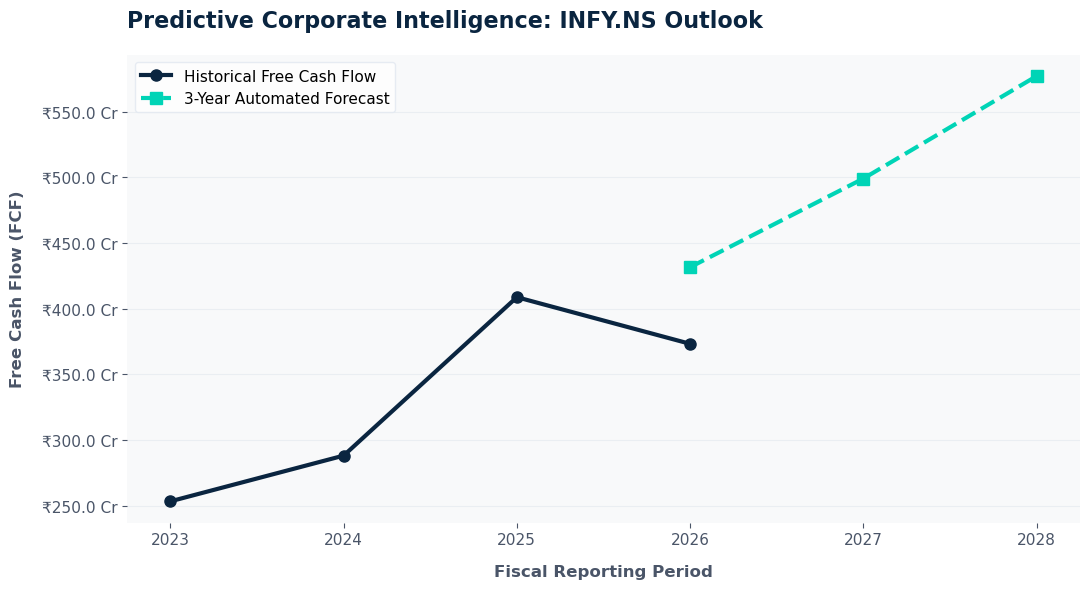

In [2]:
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker_format

print("--- Step 1: Preparing data & clean string dates... ---")

# Convert index dates to simple string years to avoid format conflicts
historical_years = [str(date.year) if hasattr(date, 'year') else str(date) for date in summary_df.index]
historical_fcf_values = summary_df['Free Cash Flow'].values

# Combine years and values for seamless plotting positioning
all_years = historical_years + forecast_df['Year'].tolist()

# Define our Indian Currency Formatter (Converts raw numbers to Crores 'Cr')
# Formula: 1 Crore = 10,000,000 (10 Million)
def indian_currency_crore_formatter(x, pos):
    if abs(x) >= 1e7:
        return f'₹{x / 1e7:,.1f} Cr'
    elif abs(x) == 0:
        return '₹0'
    else:
        return f'₹{x:,.0f}'

# --- Step 2: Modern UI Design Layout (LinkedIn Aspect Ratio) ---
fig, ax = plt.subplots(figsize=(11, 6), facecolor='#ffffff')
ax.set_facecolor('#f8f9fa') # Soft off-white canvas background

# Plot Historical Data Line (Premium Navy)
ax.plot(historical_years, historical_fcf_values, 
        label='Historical Free Cash Flow', 
        marker='o', markersize=8, linewidth=3, 
        color='#0a2540', zorder=3)

# Plot Forecasted Data Line (Dynamic Emerald Green)
ax.plot(forecast_df['Year'], forecast_df['Projected FCF'], 
        label='3-Year Automated Forecast', 
        linestyle='--', marker='s', markersize=8, linewidth=3, 
        color='#00d4b6', zorder=3)

# --- Step 3: Text & Polish Infrastructure ---
ax.set_title(f'Predictive Corporate Intelligence: {ticker} Outlook', 
             fontsize=16, fontweight='bold', pad=20, color='#0a2540', loc='left')

ax.set_xlabel('Fiscal Reporting Period', fontsize=12, fontweight='semibold', labelpad=12, color='#4a5568')
ax.set_ylabel('Free Cash Flow (FCF)', fontsize=12, fontweight='semibold', labelpad=12, color='#4a5568')

# Apply our custom Indian Currency Formatter to the Y-Axis
ax.yaxis.set_major_formatter(ticker_format.FuncFormatter(indian_currency_crore_formatter))

# Clean up structural borders (Spines) for a modern, borderless look
for spine in ['top', 'right', 'left', 'bottom']:
    ax.spines[spine].set_visible(False)

# Add soft background gridlines running only horizontally
ax.grid(axis='y', linestyle='-', alpha=0.3, color='#cbd5e1', zorder=1)
ax.tick_params(axis='both', colors='#4a5568', labelsize=11)

# Add an elegant, clean legend box
ax.legend(loc='upper left', frameon=True, facecolor='#ffffff', edgecolor='#e2e8f0', fontsize=11)

plt.tight_layout()

# --- Step 4: Export Premium Asset ---
output_filename = f"{ticker.split('.')[0]}_linkedin_insight.png"
plt.savefig(output_filename, dpi=300, facecolor=fig.get_facecolor(), bbox_inches='tight')
print(f"\n--- Success! LinkedIn-ready asset saved as: {output_filename} ---")

plt.show()



In [3]:
import os
import matplotlib.pyplot as plt

print("--- Activating Safe-Save Protocol... ---")

# 1. Define the filename cleanly
clean_ticker = ticker.split('.')[0] if 'ticker' in locals() else "STOCK"
output_filename = f"{clean_ticker}_linkedin_insight.png"

# 2. Try saving to standard Desktop first, with a fallback to OneDrive Desktop
primary_desktop = os.path.join(os.path.expanduser("~"), "Desktop")
onedrive_desktop = os.path.join(os.path.expanduser("~"), "OneDrive", "Desktop")

# Determine which path actually exists on your machine
if os.path.exists(primary_desktop):
    final_save_path = os.path.join(primary_desktop, output_filename)
elif os.path.exists(onedrive_desktop):
    final_save_path = os.path.join(onedrive_desktop, output_filename)
else:
    # Safe Fallback: Save right inside your current project folder if Desktop is blocked
    final_save_path = output_filename

try:
    # 3. Save the asset safely using the active figure
    # Using plt.gcf() (Get Current Figure) ensures it works even if 'fig' wasn't defined earlier
    current_figure = plt.gcf()
    
    current_figure.savefig(final_save_path, 
                           dpi=300, 
                           facecolor=current_figure.get_facecolor(), 
                           bbox_inches='tight')
    
    print(f"\n✅ SUCCESS! Chart saved to: {final_save_path}")

except Exception as e:
    print("\n❌ Saving failed due to system permissions. Attempting local directory save...")
    # Ultimate fallback to ensure you get your file
    plt.savefig(output_filename, dpi=300, bbox_inches='tight')
    print(f"✅ Safe fallback successful! Saved in your local folder as: {output_filename}")

plt.show()

--- Activating Safe-Save Protocol... ---

✅ SUCCESS! Chart saved to: C:\Users\Itsok\OneDrive\Desktop\INFY_linkedin_insight.png


<Figure size 640x480 with 0 Axes>